# Exploratory Data Analysis (EDA)
## Wisconsin Diagnostic Breast Cancer 

---

# 1. Dataset Overview
The [Wisconsin Diagnostic Breast Cancer dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) (WDBC) contains 569 samples (instances) of 30 real-valued input features derived from digitized images of fine needle aspirates (FNAs) of breast masses to predict tumor malignancy. Features describe 10 core characteristics of cell nuclei present in the image: radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension. Each feature is calculated in three ways — mean, standard error, and worst (mean of three largest values).

## 1.1 Load and Inspect the Data
Here, we use `sklearn`'s built-in data loader, which mirror's the WDBC dataset from [UCI Machine Learning Repository](https://archive.ics.uci.edu/) website.

In [1]:
# data manipulation
import pandas as pd
import numpy as np

# dataset
from ucimlrepo import fetch_ucirepo
from sklearn.datasets import load_breast_cancer

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# processing
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", context="notebook")
print("> Loaded required libraries")


> Loaded required libraries


In [2]:
# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns = data.feature_names) # add features

# re-map target to categorical: 0=Malignant, 1=Benign
df["diagnosis"] = data.target
df["diagnosis"] = pd.Categorical(
    df["diagnosis"].map({0: "malignant", 1: "benign"}),
    categories = data.target_names
)

# get overview
print(f"Shape of dataset: {df.shape}")
print(f"Target classes: {data.target_names}")
print(f"Features: {data.feature_names.tolist()}")

# check that there are 10 features per measurement
measures = ["mean", "error", "worst"]
for i in measures:
    print(f"{len(df.columns[df.columns.str.contains(i)])} {i} features")

df.info()

Shape of dataset: (569, 31)
Target classes: ['malignant' 'benign']
Features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
10 mean features
10 error features
10 worst features
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   mean radius              569 non-null    float64 
 1   mean texture             569 n

## 1.2 Data Cleaning
Before conducting any analyses we need to address data quality issues that could impact model quality: missing values, duplicates, and zero-variance features.

In [3]:
# Missing values
missing = df.isnull().sum()
print(f"--- Missing Values ---")
print(missing[missing >0] if missing.any() else "No missing values found.")

# Duplicate check and de-duplication if needed
dupes = df.duplicated().sum()
print(f"\n--- Duplicates ---")
print(f"{dupes} duplicate row(s) found.")
if dupes > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

# Constant (zero) variance


--- Missing Values ---
No missing values found.

--- Duplicates ---
0 duplicate row(s) found.


## 1.3 Class Distribution

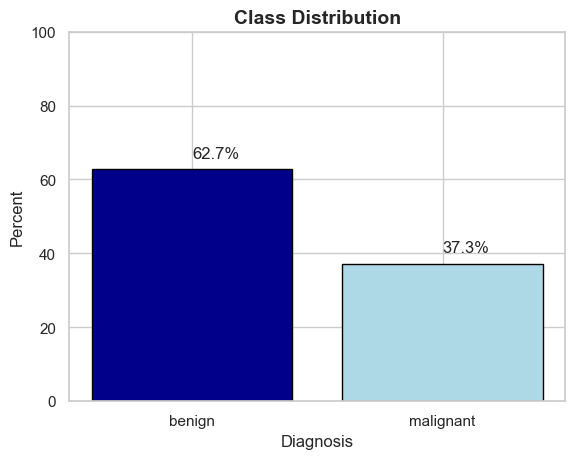

In [4]:
counts = df['diagnosis'].value_counts(normalize=True) * 100

# quick barplot
plt.bar(counts.index,counts.values,color=['darkblue','lightblue'],edgecolor="black")
plt.title("Class Distribution", fontsize=14,fontweight="bold")
plt.xlabel("Diagnosis")
plt.ylabel("Percent")
plt.ylim(0,100)
for i, count in enumerate(counts):
    plt.text(i, count + 3,f"{count:.1f}%")

## 1.x Boxplots & Outlier Detection
Next, we will check for potential outliers in the dataset using boxplots. 
<!-- could potentially flag outliers as a column -->

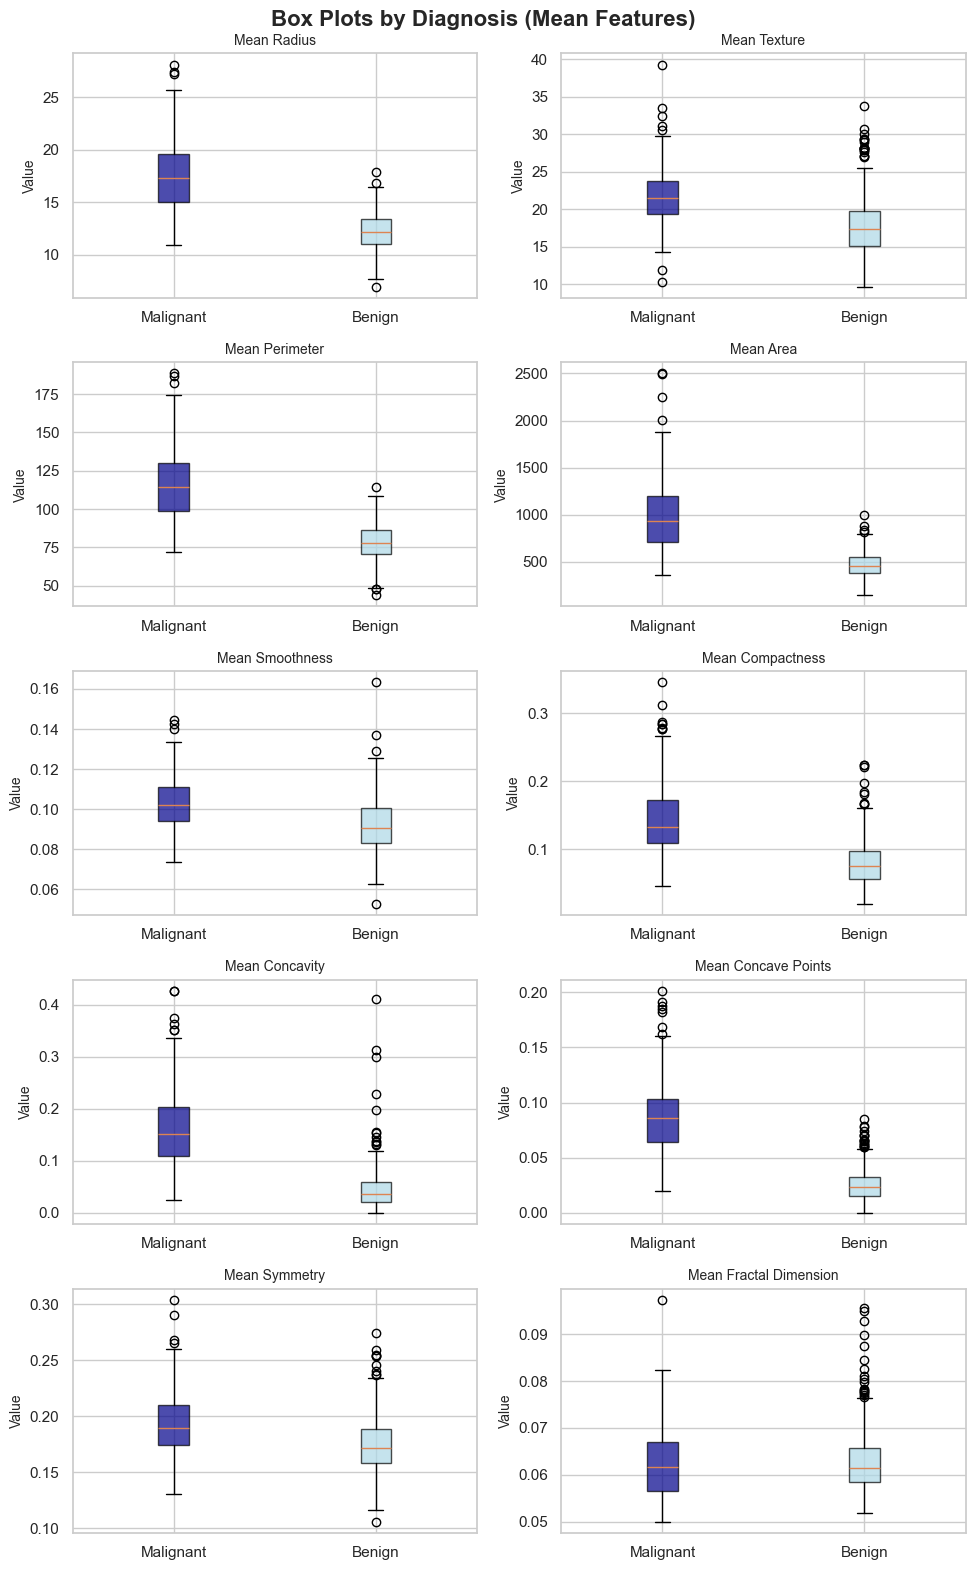

In [5]:
mean_ft = [col for col in df.columns if col.startswith("mean")]

fig, axes = plt.subplots(5,2,figsize=(10,16))
axes=axes.flatten()

for i, ft in enumerate(mean_ft):
    m = df[df["diagnosis"] == "malignant"][ft]
    b = df[df["diagnosis"] == "benign"][ft]

    bp = axes[i].boxplot(
        [m,b],tick_labels=["Malignant","Benign"],
        patch_artist=True,notch=False
    )
    bp["boxes"][0].set_facecolor("darkblue")
    bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor("lightblue")
    bp["boxes"][1].set_alpha(0.7)

    axes[i].set_title(ft.title(),fontsize=10)
    axes[i].set_ylabel("Value", fontsize=10)

plt.suptitle("Box Plots by Diagnosis (Mean Features)",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()


## 1.4 Feature Distribution

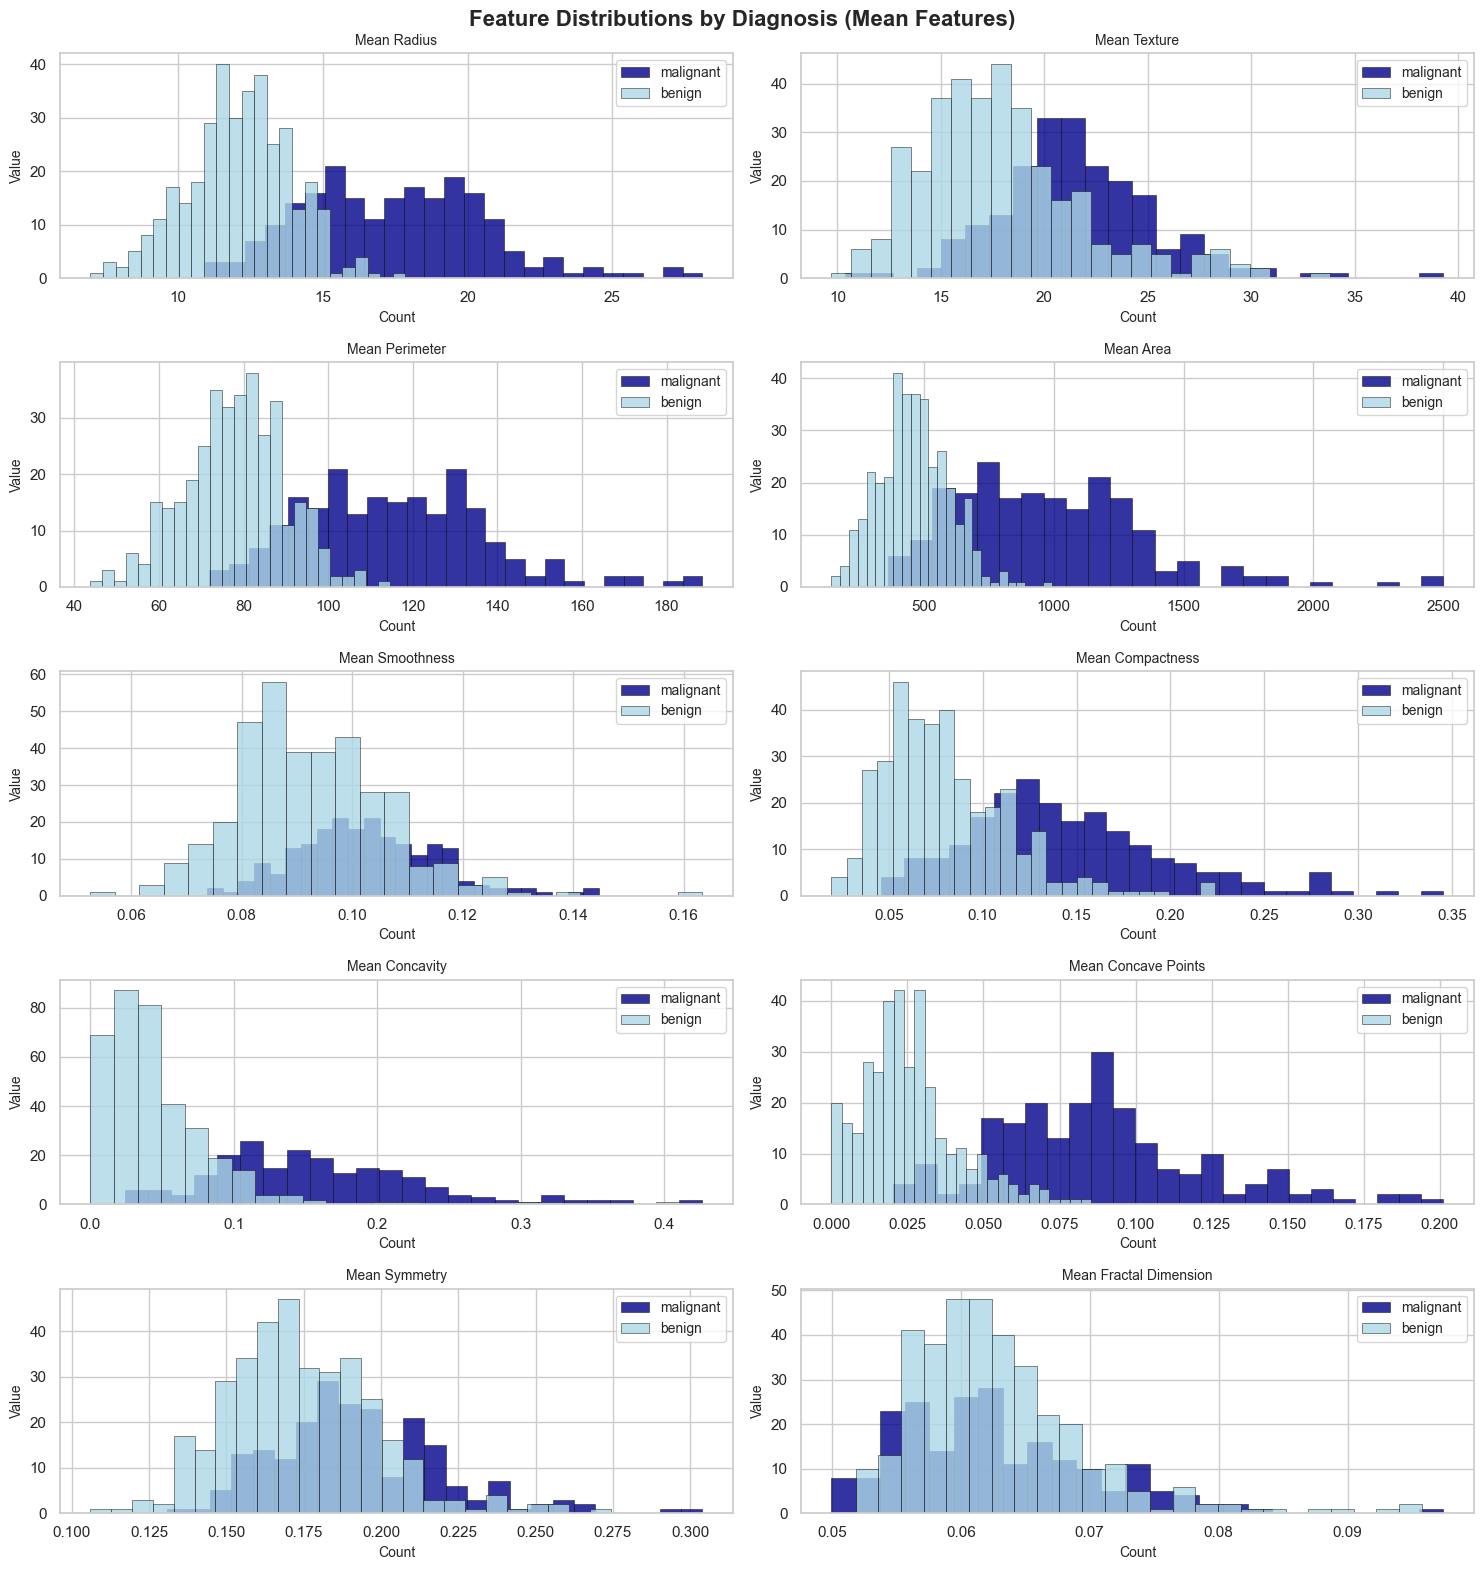

In [6]:
## 1.4 Feature Distribution
mean_ft = [col for col in df.columns if col.startswith("mean")]

colors = ["darkblue","lightblue"]
fig, axes = plt.subplots(5, 2, figsize=(15,16))
axes = axes.flatten()

for i, ft in enumerate (mean_ft):
    for dx, col in [("malignant",colors[0]),("benign",colors[1])]:
        subset = df[df["diagnosis"] == dx][ft]
        axes[i].hist(subset,bins=25,alpha=0.8,color=col,label=dx,edgecolor="black",linewidth=0.4)
    
    axes[i].set_title(ft.title(),fontsize=10)
    axes[i].set_ylabel('Value',fontsize=10)
    axes[i].set_xlabel('Count',fontsize=10)
    axes[i].legend(fontsize=10)

plt.suptitle("Feature Distributions by Diagnosis (Mean Features)",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()

## 1.5 Key Feature Relationships


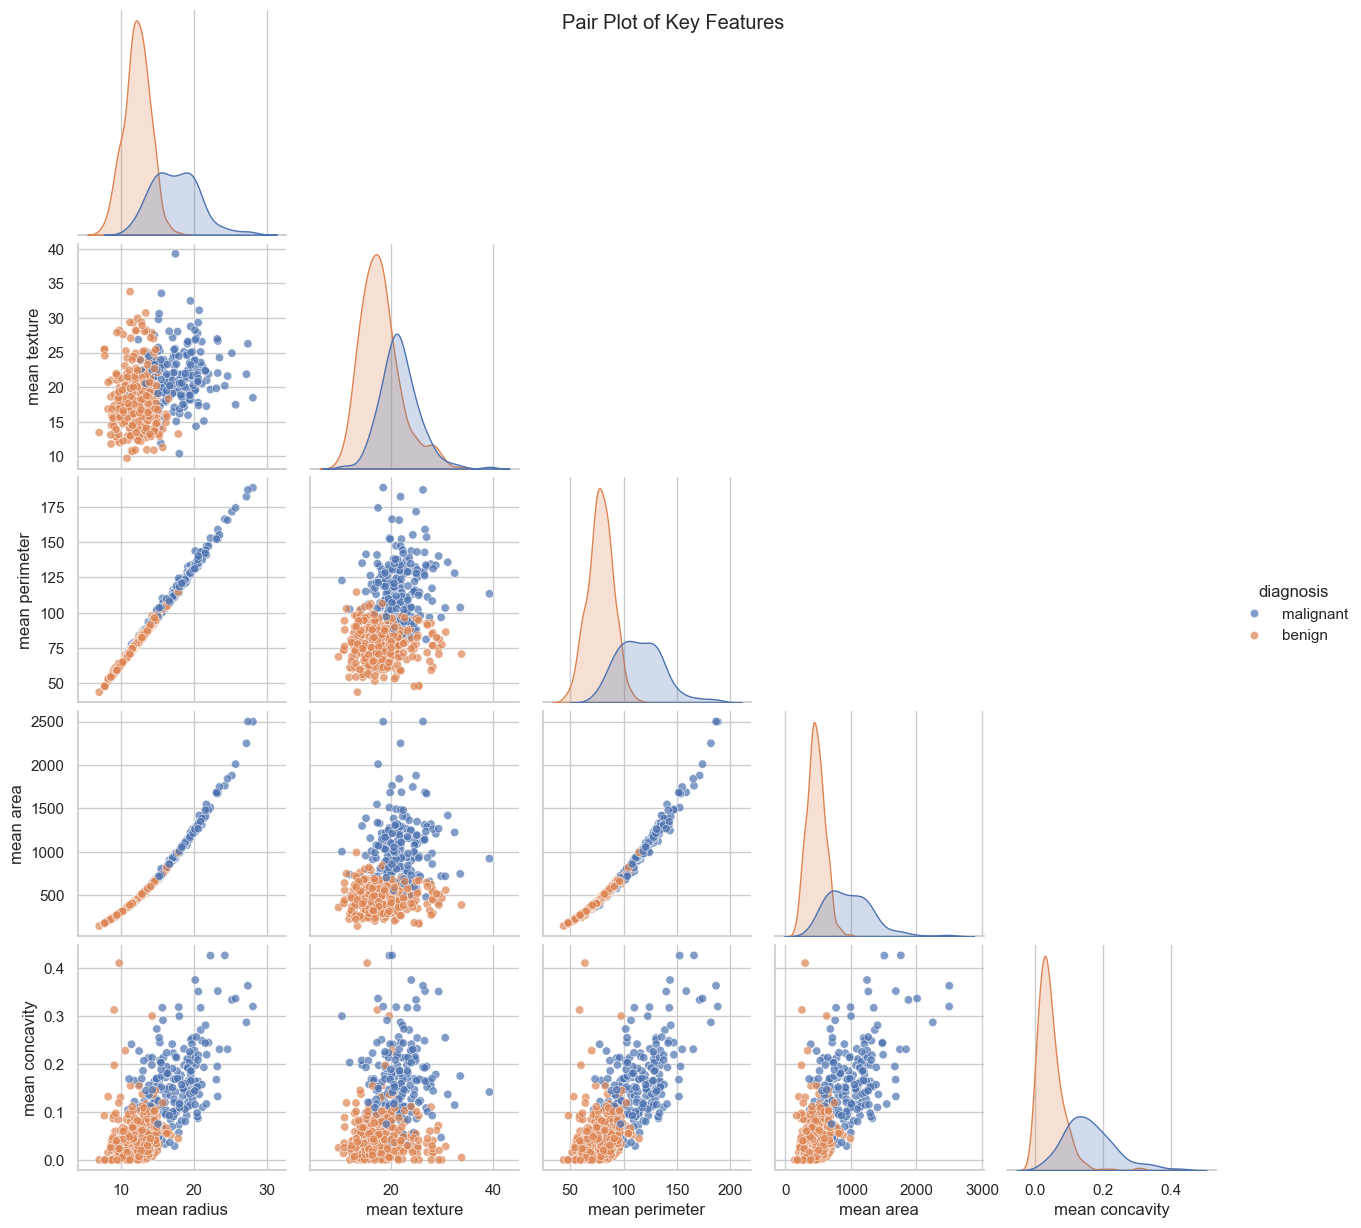

In [7]:
# select some strongly discriminative features
features = ["mean radius","mean texture","mean perimeter","mean area","mean concavity"]

sns.pairplot(df, vars=features,hue="diagnosis",diag_kind="kde",corner=True,plot_kws={"alpha":0.7})
plt.suptitle("Pair Plot of Key Features")
plt.show()

## 1.6 Correlation Heatmap
For examining collinearity

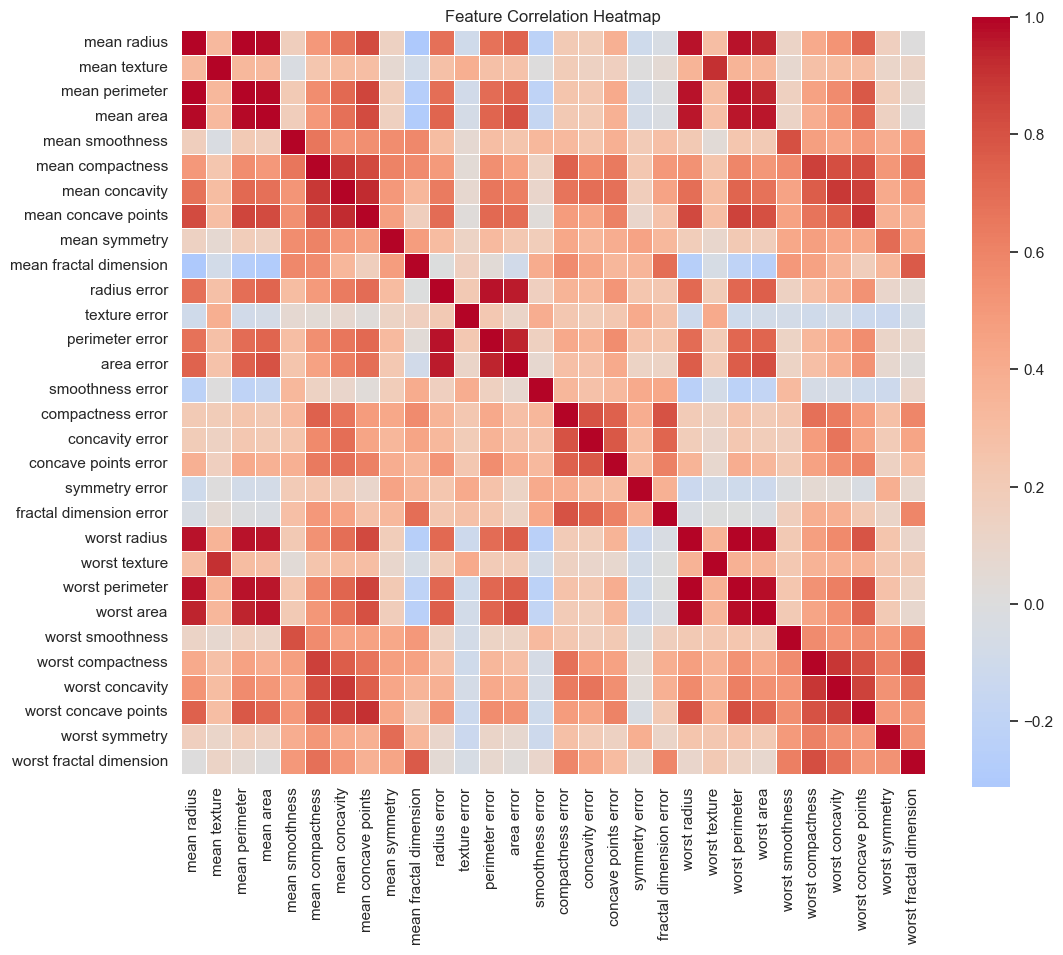

In [8]:
plt.figure(figsize=(12,10))

corr = df.drop(columns="diagnosis").corr()

sns.heatmap(corr,cmap="coolwarm",center=0,square=True,linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

--- 

Author: SE Creighton

_Last Updated: 2026-02-28_
